|Machine Learning Lab Assignment 02 |                   |          
|-----------------------------------|:-----------------:|
|**Nightly Sleep Time And GPA In First-Years**    |         |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

# Nightly sleep time and GPA in first-years

#### Does nightly sleep duration predict change in end-of-semester grade point average (GPA)? First-year college students from three independent universities provided sleep actigraphy for a month early in their spring academic term across five studies.

# Goal 1 : Create plots comparing the term GPAs by gender, race, and first generation status, which may all be related to academic success. Then, conduct one-way ANOVA analyses to see whether GPA differs across different groups.

In [2]:
import pandas as pd

df = pd.read_csv("cmu-sleep.csv")
df

,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.000000,3.380000,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.660000,2.600000,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.570000,3.070000,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.610000,3.560000,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.210000,4.000000,61,1.958280544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,99978,4,nh,0,0,0,0.091325,383.448276,407.931035,0.966667,44.344828,3.722167,3.611333,,
630,61,2,uw1,0,1,,0.045369,477.894737,331.315789,0.678571,23.631579,3.868182,3.650000,10,-1.80457982
631,172,2,uw1,1,1,,0.075429,407.153846,387.269231,0.928571,12.384615,3.727272,3.600000,15,0.373361342
632,110,2,uw1,1,0,,0.200289,397.125000,487.583333,0.857143,99.541667,3.337500,3.538461,13,-0.497815123


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   cohort                 634 non-null    object 
 3   demo_race              634 non-null    object 
 4   demo_gender            634 non-null    object 
 5   demo_firstgen          634 non-null    object 
 6   bedtime_mssd           634 non-null    float64
 7   TotalSleepTime         634 non-null    float64
 8   midpoint_sleep         634 non-null    float64
 9   frac_nights_with_data  634 non-null    float64
 10  daytime_sleep          634 non-null    float64
 11  cum_gpa                634 non-null    float64
 12  term_gpa               634 non-null    float64
 13  term_units             634 non-null    object 
 14  Zterm_units_ZofZ       634 non-null    object 
dtypes: flo

In [14]:
unique_races = df['demo_race'].unique()
unique_genders = df['demo_gender'].unique()
unique_firstgen = df['demo_firstgen'].unique()

print("Unique values in 'demo_race':", unique_races)
print("Unique values in 'demo_gender':", unique_genders)
print("Unique values in 'demo_firstgen':", unique_firstgen)

Unique values in 'demo_race': ['1' '0' ' ']
Unique values in 'demo_gender': ['1' '0' ' ']
Unique values in 'demo_firstgen': ['0' '1' '2' ' ']


In [20]:
df_clean = df.copy()

df_clean = df_clean[df_clean['demo_race'] != ' ']
df_clean = df_clean[df_clean['demo_gender'] != ' ']
df_clean = df_clean[df_clean['demo_firstgen'] != '2']
df_clean = df_clean[df_clean['demo_firstgen'] != ' ']

print("Unique values in 'demo_race' after cleaning:", df_clean['demo_race'].unique())
print("Unique values in 'demo_gender' after cleaning:", df_clean['demo_gender'].unique())
print("Unique values in 'demo_firstgen' after cleaning:", df_clean['demo_firstgen'].unique())
print("\nNumber of rows after cleaning:", len(df_clean))

Unique values in 'demo_race' after cleaning: ['1' '0']
Unique values in 'demo_gender' after cleaning: ['1' '0']
Unique values in 'demo_firstgen' after cleaning: ['0' '1']

Number of rows after cleaning: 625



--- ANOVA Results: GPA by Gender ---
F-statistic: 0.0077
P-value: 0.9300
Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the gender groups.

--- ANOVA Results: GPA by Race ---
F-statistic: 19.3395
P-value: 0.0000
Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the race groups.

--- ANOVA Results: GPA by First Generation Status ---
F-statistic: 11.6760
P-value: 0.0007
Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the first generation status groups.


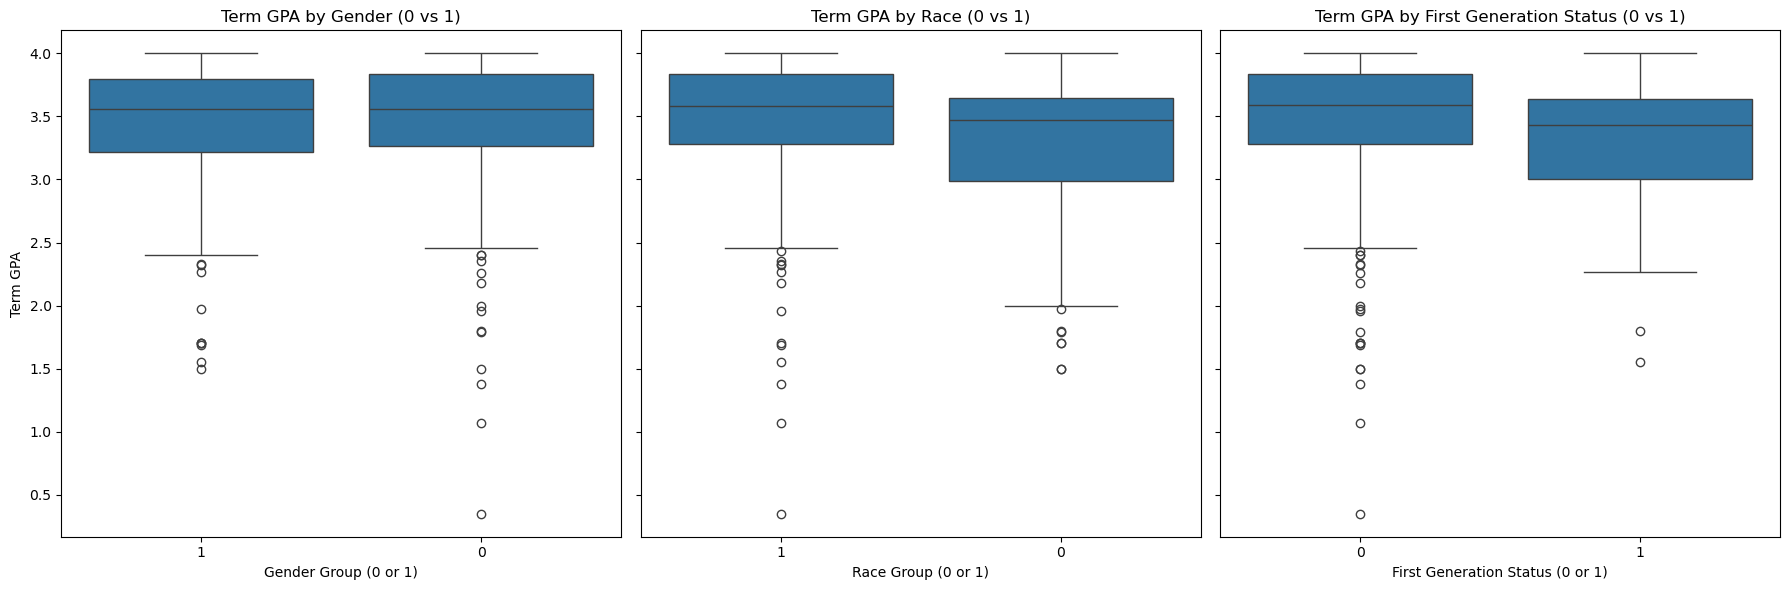

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.boxplot(x='demo_gender', y='term_gpa', data=df_clean, ax=axes[0])
axes[0].set_title('Term GPA by Gender (0 vs 1)')
axes[0].set_xlabel('Gender Group (0 or 1)')
axes[0].set_ylabel('Term GPA')

sns.boxplot(x='demo_race', y='term_gpa', data=df_clean, ax=axes[1])
axes[1].set_title('Term GPA by Race (0 vs 1)')
axes[1].set_xlabel('Race Group (0 or 1)')
axes[1].set_ylabel('') 

sns.boxplot(x='demo_firstgen', y='term_gpa', data=df_clean, ax=axes[2])
axes[2].set_title('Term GPA by First Generation Status (0 vs 1)')
axes[2].set_xlabel('First Generation Status (0 or 1)')
axes[2].set_ylabel('')  

plt.tight_layout()

plt.savefig('gpa_demographics_boxplots.png')

gender_groups = [df_clean['term_gpa'][df_clean['demo_gender'] == g] for g in ['0', '1']]
f_stat_gender, p_value_gender = stats.f_oneway(*gender_groups)
print("\n--- ANOVA Results: GPA by Gender ---")
print(f"F-statistic: {f_stat_gender:.4f}")
print(f"P-value: {p_value_gender:.4f}")
print("Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the gender groups.")

race_groups = [df_clean['term_gpa'][df_clean['demo_race'] == r] for r in ['0', '1']]
f_stat_race, p_value_race = stats.f_oneway(*race_groups)
print("\n--- ANOVA Results: GPA by Race ---")
print(f"F-statistic: {f_stat_race:.4f}")
print(f"P-value: {p_value_race:.4f}")
print("Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the race groups.")

firstgen_groups = [df_clean['term_gpa'][df_clean['demo_firstgen'] == f] for f in ['0', '1']]
f_stat_firstgen, p_value_firstgen = stats.f_oneway(*firstgen_groups)
print("\n--- ANOVA Results: GPA by First Generation Status ---")
print(f"F-statistic: {f_stat_firstgen:.4f}")
print(f"P-value: {p_value_firstgen:.4f}")
print("Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean GPA between the first generation status groups.")

# Goal 1 Result
#### One-way ANOVA analyses to see whether GPA differs across different groups.

## 1. GPA vs. Gender

#### F-statistic: 0.0077
#### P-value: 0.9300
#### There is no statistically significant difference in the mean GPA between the two gender groups. The high p-value (greater than 0.05) indicates that any observed differences are likely due to random chance.

## 2. GPA vs. Race

#### F-statistic: 19.3395
#### P-value: 0.0000
#### There is a statistically significant difference in the mean GPA between the two race groups. The very low p-value (less than 0.05) suggests that the difference in mean GPA is not due to random chance.

## 3. GPA vs. First Generation Status

#### F-statistic: 11.6760
#### P-value: 0.0007
#### There is a statistically significant difference in the mean GPA between the first generation status groups. The low p-value (less than 0.05) indicates that the difference in mean GPA is not due to random chance

# Goal 2 : Create a boxplot comparing the average total sleep time across schools.

# Goal 2 Result

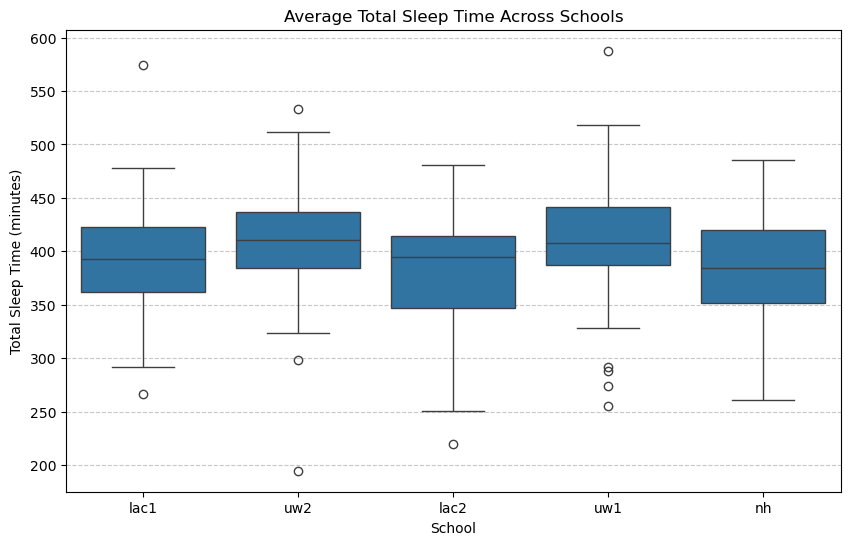

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cohort', y='TotalSleepTime', data=df)
plt.title('Average Total Sleep Time Across Schools')
plt.xlabel('School')
plt.ylabel('Total Sleep Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('total_sleep_time_by_school_boxplot.png')

# Goal 3 : Find the average total sleep time for each school. Conduct a One-Way ANOVA analysis to see whether total sleep time differs across different schools.

In [35]:
from scipy import stats

average_sleep_time_by_school = df.groupby('cohort')['TotalSleepTime'].mean().reset_index()
average_sleep_time_by_school.rename(columns={'TotalSleepTime': 'AverageTotalSleepTime'}, inplace=True)
print("Average Total Sleep Time for each school:")
print(average_sleep_time_by_school)

schools = df['cohort'].unique()

sleep_time_by_school = [df['TotalSleepTime'][df['cohort'] == school] for school in schools]

f_statistic, p_value = stats.f_oneway(*sleep_time_by_school)

print("\n--- One-Way ANOVA Results ---")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print("Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean total sleep time across the schools.")

Average Total Sleep Time for each school:
  cohort  AverageTotalSleepTime
0   lac1             391.597296
1   lac2             378.913961
2     nh             385.148055
3    uw1             412.989041
4    uw2             410.017881

--- One-Way ANOVA Results ---
F-statistic: 11.2094
P-value: 0.0000
Interpretation: A p-value less than 0.05 indicates a statistically significant difference in mean total sleep time across the schools.


# Goal 3 Result

### Average Total Sleep Time for each school

In [36]:
dataDT = {
    'cohort': ['lac1', 'lac2', 'nh', 'uw1', 'uw2'],
    'AverageTotalSleepTime': [391.597296, 378.913961, 385.148055, 412.989041, 410.017881]
}
DT = pd.DataFrame(dataDT)
DT

,cohort,AverageTotalSleepTime
0,lac1,391.597296
1,lac2,378.913961
2,nh,385.148055
3,uw1,412.989041
4,uw2,410.017881


### One-Way ANOVA Results

#### F-statistic: 11.2094
#### P-value: 0.0000
#### The very low p-value ( <0.05 ) indicates a statistically significant difference in the mean total sleep time across the five schools. This suggests that the observed differences in average sleep time among the schools are unlikely to be due to random chance.

# Goal 4 : Explore the linear relationship between total sleep time and term GPA. Is the relationship significant, controlling for cumulative GPA?

In [37]:
import statsmodels.formula.api as smf

model = smf.ols('term_gpa ~ TotalSleepTime + cum_gpa', data=df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               term_gpa   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     232.7
Date:                Sun, 17 Aug 2025   Prob (F-statistic):           1.94e-76
Time:                        12:16:10   Log-Likelihood:                -285.08
No. Observations:                 634   AIC:                             576.2
Df Residuals:                     631   BIC:                             589.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4592      0.160      2.

# Goal 4 Regression Result

##### The regression model used term_gpa as the dependent variable and both TotalSleepTime and cum_gpa as independent variables.

### P-value for TotalSleepTime: 0.000.
#### Since this p-value is much less than 0.05, we can conclude that the relationship between total sleep time and term GPA is statistically significant. The coefficient of 0.0013 suggests that for every additional minute of sleep, the term GPA is expected to increase by 0.0013, holding cumulative GPA constant.

### P-value for cum_gpa: 0.000.
#### As expected, the relationship between cumulative GPA and term GPA is also highly significant. The coefficient of 0.7130 indicates a strong positive relationship.

### R-squared: 0.425.
#### This value indicates that approximately 42.5% of the variance in term GPA can be explained by the total sleep time and cumulative GPA combined.

# Goal 5 : Total sleep time of a student from CMU is 360. What is his/her predicted GPA?

# Goal 5 Result

In [42]:
average_cum_gpa = df['cum_gpa'].mean()

model = smf.ols('term_gpa ~ TotalSleepTime + cum_gpa', data=df)
results = model.fit()
intercept = results.params['Intercept']
coef_sleep = results.params['TotalSleepTime']
coef_cum_gpa = results.params['cum_gpa']

total_sleep_time_minutes = 360

predicted_gpa = intercept + (total_sleep_time_minutes * coef_sleep) + (average_cum_gpa * coef_cum_gpa)

print(f"Predicted Term GPA (with 360 minutes of sleep): {predicted_gpa:.2f}")

Predicted Term GPA (with 360 minutes of sleep): 3.40


# CONCLUSION

## In this project, I learned one-way ANOVA analysis with practical implementation on a real world dataset. Furthur I explored relationship between features of the datasets and understood significance of p-value. 